# Milestone 3: Chemo-kinematic Feature Construction

This notebook constructs a first chemo-kinematic feature table from the Gaia–LAMOST crossmatched pilot sample.

The goal of this milestone is not to make final Galactic archaeology conclusions, but to validate the workflow from:

Gaia astrometry + photometry  
+ LAMOST spectroscopy  

to:

kinematic features  
+ chemical grouping  
+ simple population candidate flags.

Current sample size: 138 stars.

This should be treated as a pilot sample / workflow validation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

input_path = DATA_PROCESSED / "gaia_lamost_crossmatched_sample.csv"
output_path = DATA_PROCESSED / "gaia_lamost_chemo_kinematic_features.csv"

FIGURES_DIR.mkdir(exist_ok=True)

input_path

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_crossmatched_sample.csv')

In [3]:
df = pd.read_csv(input_path)

print(f"Rows: {len(df)}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows: 138
Columns: 29


,source_id,ra_gaia,dec_gaia,parallax,parallax_over_error,pmra,pmdec,phot_g_mean_mag,bp_rp,ruwe,...,subclass,teff,teff_err,logg,logg_err,feh,feh_err,rv,rv_err,id_match_sep_arcsec
0,3084445095932542080,121.282228,0.512150,4.631884,188.207570,-15.153145,7.702148,11.034749,0.794672,1.306483,...,G3,5803.46,33.10,4.258,0.044,0.126,0.025,34.19,5.32,0.242143
1,3084578720955039744,121.989146,0.908265,0.533697,17.030481,-2.469817,-4.160283,15.088555,1.045016,1.016637,...,K1,5302.44,25.63,4.460,0.036,0.376,0.022,4.91,3.42,0.125105
2,3084637098150125952,120.988289,1.186262,0.775818,32.108326,-5.144803,-2.841027,14.425479,0.814630,0.994611,...,G2,5875.14,31.16,4.197,0.042,0.010,0.024,35.19,4.74,0.166579
3,3084669224505393280,121.516145,1.450176,1.684938,98.572060,4.752070,-2.820532,12.842078,0.822827,1.024657,...,G4,5802.57,30.05,4.479,0.042,0.003,0.025,-7.17,4.05,0.134519
4,3083675540871959552,121.939753,0.275229,2.397850,169.145070,-13.858935,-15.213946,10.664133,1.070729,1.062962,...,G5,5119.94,27.59,3.534,0.038,0.000,0.022,-14.13,3.96,0.201203


In [4]:
required_columns = [
    "source_id",
    "ra_gaia",
    "dec_gaia",
    "parallax",
    "parallax_over_error",
    "pmra",
    "pmdec",
    "phot_g_mean_mag",
    "bp_rp",
    "ruwe",
    "distance_pc",
    "absolute_g_mag",
    "teff",
    "logg",
    "feh",
    "rv",
    "snrg",
    "id_match_sep_arcsec",
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print("Missing columns:")
    print(missing_columns)
else:
    print("All required columns are present.")

All required columns are present.


In [5]:
# Construct basic kinematic features

df_features = df.copy()

# Total proper motion in mas/yr
df_features["pm_total"] = np.sqrt(
    df_features["pmra"]**2 + df_features["pmdec"]**2
)

# Tangential velocity in km/s
# Formula: v_tan = 4.74047 * pm_total / parallax
# pm_total: mas/yr, parallax: mas
df_features["tangential_velocity_kms"] = (
    4.74047 * df_features["pm_total"] / df_features["parallax"]
)

# Reduced proper motion in Gaia G band
# H_G = G + 5 * log10(mu_arcsec_per_year) + 5
pm_total_arcsec_per_year = df_features["pm_total"] / 1000

df_features["reduced_pm_g"] = (
    df_features["phot_g_mean_mag"]
    + 5 * np.log10(pm_total_arcsec_per_year)
    + 5
)

df_features[
    [
        "source_id",
        "pmra",
        "pmdec",
        "parallax",
        "pm_total",
        "tangential_velocity_kms",
        "reduced_pm_g",
    ]
].head()

,source_id,pmra,pmdec,parallax,pm_total,tangential_velocity_kms,reduced_pm_g
0,3084445095932542080,-15.153145,7.702148,4.631884,16.998261,17.396754,7.186771
1,3084578720955039744,-2.469817,-4.160283,0.533697,4.838177,42.974226,8.511964
2,3084637098150125952,-5.144803,-2.841027,0.775818,5.877110,35.910828,8.271298
3,3084669224505393280,4.752070,-2.820532,1.684938,5.526081,15.547292,6.554164
4,3083675540871959552,-13.858935,-15.213946,2.397850,20.579948,40.685867,7.231354


In [6]:
kinematic_columns = [
    "pm_total",
    "tangential_velocity_kms",
    "reduced_pm_g",
]

df_features[kinematic_columns].describe()

,pm_total,tangential_velocity_kms,reduced_pm_g
count,138.000000,138.000000,138.000000
mean,13.884052,35.371707,8.130983
std,10.790890,22.067510,1.634258
min,0.929246,1.599143,2.455304
25%,6.096044,18.667658,7.151382
50%,10.170952,32.052241,8.349556
75%,19.086736,45.321038,9.182741
max,53.619881,131.657847,11.374678


In [7]:
df_features[
    [
        "pmra",
        "pmdec",
        "parallax",
        "phot_g_mean_mag",
        "pm_total",
        "tangential_velocity_kms",
        "reduced_pm_g",
    ]
].isna().sum()

pmra                       0
pmdec                      0
parallax                   0
phot_g_mean_mag            0
pm_total                   0
tangential_velocity_kms    0
reduced_pm_g               0
dtype: int64

In [8]:
# Construct metallicity groups based on [Fe/H]

def assign_metallicity_group(feh):
    if pd.isna(feh):
        return "unknown"
    elif feh < -0.5:
        return "metal_poor"
    elif feh <= 0.2:
        return "solar_like"
    else:
        return "metal_rich"


df_features["metallicity_group"] = df_features["feh"].apply(assign_metallicity_group)

df_features["metallicity_group"].value_counts()

metallicity_group
solar_like    114
metal_rich     21
metal_poor      3
Name: count, dtype: int64

In [9]:
# Construct simple population candidate flags
# These are not final classifications.
# They are only used to validate the candidate selection workflow.

df_features["high_vtan_candidate"] = (
    df_features["tangential_velocity_kms"] > 100
)

df_features["metal_poor_candidate"] = (
    df_features["feh"] < -0.5
)

df_features["chemo_kinematic_candidate"] = (
    df_features["high_vtan_candidate"]
    & df_features["metal_poor_candidate"]
)

candidate_columns = [
    "high_vtan_candidate",
    "metal_poor_candidate",
    "chemo_kinematic_candidate",
]

df_features[candidate_columns].sum()

high_vtan_candidate          1
metal_poor_candidate         3
chemo_kinematic_candidate    0
dtype: int64

In [10]:
candidate_view_columns = [
    "source_id",
    "ra_gaia",
    "dec_gaia",
    "parallax",
    "pm_total",
    "tangential_velocity_kms",
    "rv",
    "feh",
    "metallicity_group",
    "high_vtan_candidate",
    "metal_poor_candidate",
    "chemo_kinematic_candidate",
]

df_features.loc[
    df_features["high_vtan_candidate"] | df_features["metal_poor_candidate"],
    candidate_view_columns
].sort_values(
    by=["chemo_kinematic_candidate", "tangential_velocity_kms"],
    ascending=[False, False]
)

,source_id,ra_gaia,dec_gaia,parallax,pm_total,tangential_velocity_kms,rv,feh,metallicity_group,high_vtan_candidate,metal_poor_candidate,chemo_kinematic_candidate
99,3084495467307744512,120.315337,0.557752,1.804344,50.112331,131.657847,48.34,-0.414,solar_like,True,False,False
33,3084461004490554496,121.066129,0.616167,1.989478,30.627250,72.977721,53.72,-0.516,metal_poor,False,True,False
94,3084501686420570112,120.577602,0.724093,1.824698,23.395766,60.780974,129.48,-0.579,metal_poor,False,True,False
13,3084464165586456704,121.074370,0.712340,2.752703,32.982676,56.799938,27.57,-0.538,metal_poor,False,True,False


## Validation plots

The following plots provide a first validation of the chemo-kinematic feature construction.

Because the current sample contains only 138 stars, these plots should be interpreted as workflow validation rather than final scientific results.

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_vtan_distribution.png')

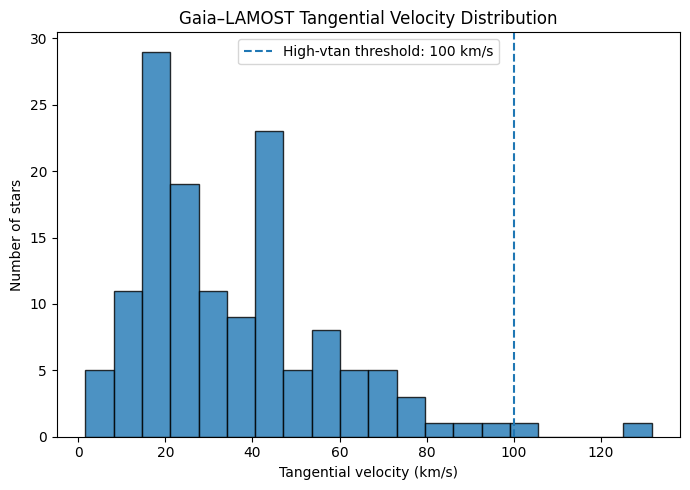

In [12]:
# Plot tangential velocity distribution

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    df_features["tangential_velocity_kms"],
    bins=20,
    edgecolor="black",
    alpha=0.8,
)

ax.axvline(
    100,
    linestyle="--",
    linewidth=1.5,
    label="High-vtan threshold: 100 km/s",
)

ax.set_xlabel("Tangential velocity (km/s)")
ax.set_ylabel("Number of stars")
ax.set_title("Gaia–LAMOST Tangential Velocity Distribution")
ax.legend()

fig.tight_layout()

vtan_dist_path = FIGURES_DIR / "gaia_lamost_vtan_distribution.png"
fig.savefig(vtan_dist_path, dpi=200)

vtan_dist_path

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_vtan_vs_feh.png')

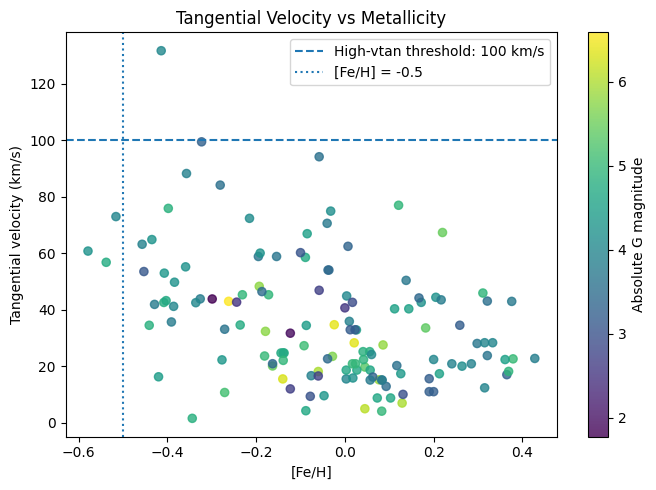

In [17]:
# Plot tangential velocity versus metallicity

fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(
    df_features["feh"],
    df_features["tangential_velocity_kms"],
    c=df_features["absolute_g_mag"],
    s=35,
    alpha=0.8,
)

ax.axhline(
    100,
    linestyle="--",
    linewidth=1.5,
    label="High-vtan threshold: 100 km/s",
)

ax.axvline(
    -0.5,
    linestyle=":",
    linewidth=1.5,
    label="[Fe/H] = -0.5",
)

ax.set_xlabel("[Fe/H]")
ax.set_ylabel("Tangential velocity (km/s)")
ax.set_title("Tangential Velocity vs Metallicity")

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Absolute G magnitude")

ax.legend()

fig.tight_layout()

vtan_feh_path = FIGURES_DIR / "gaia_lamost_vtan_vs_feh.png"
fig.savefig(vtan_feh_path, dpi=200)

vtan_feh_path

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_cmd_colored_by_vtan.png')

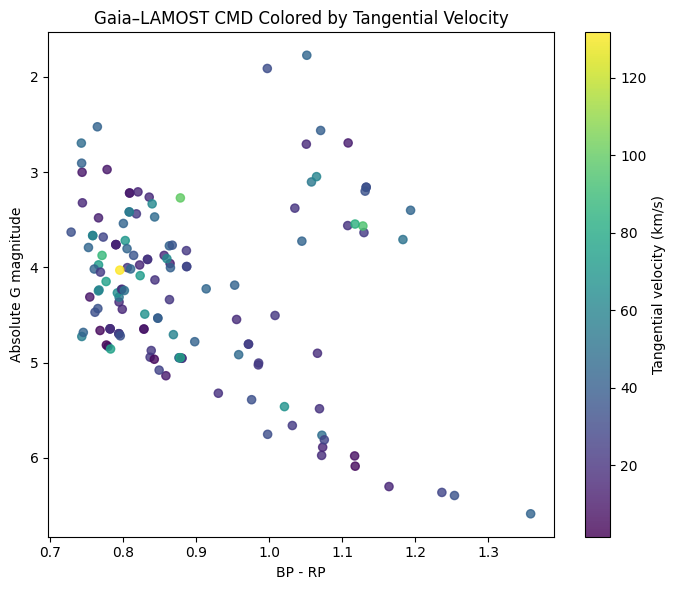

In [18]:
# Plot CMD colored by tangential velocity

fig, ax = plt.subplots(figsize=(7, 6))

scatter = ax.scatter(
    df_features["bp_rp"],
    df_features["absolute_g_mag"],
    c=df_features["tangential_velocity_kms"],
    s=35,
    alpha=0.8,
)

ax.set_xlabel("BP - RP")
ax.set_ylabel("Absolute G magnitude")
ax.set_title("Gaia–LAMOST CMD Colored by Tangential Velocity")
ax.invert_yaxis()

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Tangential velocity (km/s)")

fig.tight_layout()

cmd_vtan_path = FIGURES_DIR / "gaia_lamost_cmd_colored_by_vtan.png"
fig.savefig(cmd_vtan_path, dpi=200)

cmd_vtan_path

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_reduced_pm_diagram.png')

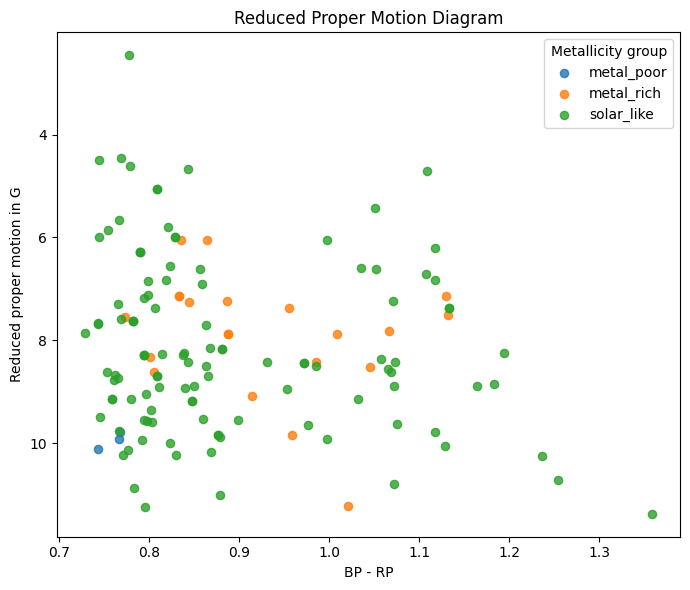

In [19]:
# Plot reduced proper motion diagram

fig, ax = plt.subplots(figsize=(7, 6))

for group, group_df in df_features.groupby("metallicity_group"):
    ax.scatter(
        group_df["bp_rp"],
        group_df["reduced_pm_g"],
        s=35,
        alpha=0.8,
        label=group,
    )

ax.set_xlabel("BP - RP")
ax.set_ylabel("Reduced proper motion in G")
ax.set_title("Reduced Proper Motion Diagram")
ax.invert_yaxis()
ax.legend(title="Metallicity group")

fig.tight_layout()

rpm_path = FIGURES_DIR / "gaia_lamost_reduced_pm_diagram.png"
fig.savefig(rpm_path, dpi=200)

rpm_path

In [21]:
# Save the chemo-kinematic feature table

df_features.to_csv(output_path, index=False)

print(f"Saved feature table to: {output_path}")
print(df_features.shape)

Saved feature table to: /Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_chemo_kinematic_features.csv
(138, 36)


In [22]:
new_feature_columns = [
    "pm_total",
    "tangential_velocity_kms",
    "reduced_pm_g",
    "metallicity_group",
    "high_vtan_candidate",
    "metal_poor_candidate",
    "chemo_kinematic_candidate",
]

df_features[new_feature_columns].head()

,pm_total,tangential_velocity_kms,reduced_pm_g,metallicity_group,high_vtan_candidate,metal_poor_candidate,chemo_kinematic_candidate
0,16.998261,17.396754,7.186771,solar_like,False,False,False
1,4.838177,42.974226,8.511964,metal_rich,False,False,False
2,5.877110,35.910828,8.271298,solar_like,False,False,False
3,5.526081,15.547292,6.554164,solar_like,False,False,False
4,20.579948,40.685867,7.231354,solar_like,False,False,False


## Milestone 3 summary

In this notebook, we constructed a first chemo-kinematic feature table from the Gaia–LAMOST crossmatched pilot sample.

New features added:
- `pm_total`
- `tangential_velocity_kms`
- `reduced_pm_g`
- `metallicity_group`
- `high_vtan_candidate`
- `metal_poor_candidate`
- `chemo_kinematic_candidate`

Validation products generated:
- tangential velocity distribution
- tangential velocity versus metallicity
- CMD colored by tangential velocity
- reduced proper motion diagram

This milestone should be interpreted as workflow validation on a small pilot sample (138 stars), not as a final Galactic archaeology result.